# Implementing FEM in python

When we translate finite element algorithms from textbooks into working code, we encounter a fundamental mismatch between the natural, 1-based indexing of mathematical notation and the 0-based indexing inherent to programming languages like Python. This chapter examines this problem not as a mere inconvenience, but as a source of cognitive friction that complicates implementation, introduces errors, and distracts from the core engineering task. We will explore the origins of this divide and present a systematic Python-based solution that preserves the clarity of mathematical notation while leveraging the full power of the Python ecosystem.

## The Disconnect: Mathematical Elegance vs. Computational Convention

Finite element analysis, like much of engineering mathematics, is expressed using 1-based indexing. We label nodes $1, 2, 3, \dots, N$ and elements $1, 2, 3, \dots, M$. This is not an arbitrary choice; it is the language of counting, embedded in research papers, textbooks but also in commercial software mesh files. An element's connectivity is defined by the nodes it connects, for example, element 1 might connect nodes 1 and 2. The degrees of freedom (DOFs) for node $i$ in a 2D problem are naturally identified as $2i-1$ and $2i$. This notation is the shared language of the discipline.

Python, inheriting its conventions from the C programming language, uses 0-based indexing for arrays. This convention originated not from mathematical necessity, but from the convenience of pointer arithmetic in 1970s-era systems programming, where `array[i]` was syntactic sugar for accessing a memory offset `*(array + i)`. While perfectly suited for low-level programming, this choice creates a persistent translation burden in scientific computing. The first node is at index 0, the first element is at index 0, and the DOF mapping becomes $2i$ and $2i+1$. 

The result is a cognitive gap between the elegant mathematics on the whiteboard and the awkward implementation in the code. Every array access requires a mental conversion, a constant subtraction or addition of one. This is more than a trivial annoyance; it is a recurring source of bugs and a barrier to clear thought. We are forced to dedicate mental energy to index arithmetic—a task that computers should handle for us.

## Code That Reads Like Mathematics

In a 1-indexed environment like MATLAB or Julia, the code is a direct transcription of the mathematical model. There is no gap between the formulas in the textbook and the implementation on the computer. Consider the simple truss from [Visualizing Truss Mesh](TrussViz.ipynb):

![Example truss](graphics/SystematicTrussAnalysis-2.png){fig-align="center" width=20em #fig-truss}

```matlab
% Node coordinates (mm)
P = [0 0
     500 0
     300 300
     600 300];

% Element connectivity (1-based node numbers)
elements = [1 2
            1 3
            2 3
            2 4
            3 4];

figure
hold on
patch('Faces',edges,'Vertices',P,'LineWidth',2)
plot(P(:,1),P(:,2),'ok','MarkerFaceColor','c','MarkerSize',14)
nnod = size(P,1);
text(P(:,1)-0.05,P(:,2),cellstr(num2str([1:nnod]')))
axis equal
axis off
for iel=1:5
    inod = edges(iel,:);
    xm = mean(P(inod,1));
    ym = mean(P(inod,2));
    text(xm,ym,num2str(iel),'backgroundColor','y')
end
```

Observe how naturally this code flows. The loop `for i=1:5` uses an index `i` that is the element number. The code reads like a direct transcription of our mathematical notation, freeing the engineer to think about the physics, not the programming language's historical quirks.

## Python: The Translation Burden

Now, we attempt the same task in Python using standard NumPy arrays. We immediately face the indexing mismatch. Accessing "node 3" must be indexed as `P[2]`, and "element 1" is at `elements[0]`. This imposes a systematic translation burden that clutters the code and obscures its logic.

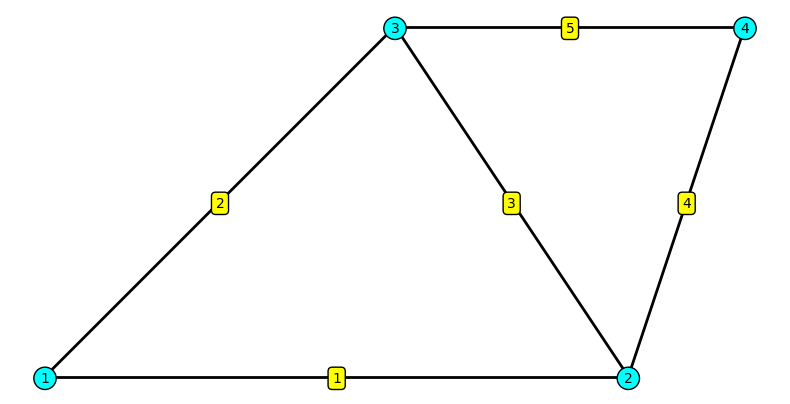

In [1]:
# | code-fold: false
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates (mm)
P = np.array([[0, 0],
              [500, 0],
              [300, 300],
              [600, 300]])

# Element connectivity (1-based node numbers)
elements = np.array([[1, 2],
                     [1, 3],
                     [2, 3],
                     [2, 4],
                     [3, 4]])

fig, ax = plt.subplots(figsize=(8, 6))

# Draw elements
for iel in range(0, 5):
    inode = elements[iel] - 1  # Convert to 0-based for NumPy
    coords = P[inode, :]
    ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=2)

# Label nodes
for inode in range(0, 4):
    coord = P[inode, :]
    ax.text(coord[0], coord[1]-5, str(inode + 1),  # Must add 1 for label!
            bbox=dict(boxstyle='circle', facecolor='cyan'),
            fontsize=10, ha='center')

# Label elements  
for iel in range(0, 5):
    inode = elements[iel] - 1  # Convert to 0-based for NumPy
    coords = P[inode, :]
    xm = np.mean(coords[:, 0])
    ym = np.mean(coords[:, 1])
    ax.text(xm, ym-5, str(iel+1),  # Must add 1 for label!
            bbox=dict(boxstyle='round', facecolor='yellow'),
            fontsize=10, ha='center')

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

The code is now littered with `+1` and `-1` corrections. We must constantly translate between the 1-based world of our physical model and the 0-based world of the array implementation. This is not merely an aesthetic issue; it is a cognitive burden that creates a persistent source of off-by-one errors, the most common and frustrating bugs in FEM programming.

## The Deeper Problem: Matrix and Tensor Indexing

The indexing problem extends beyond simple iteration and into the fundamental representation of matrices and tensors, which are the bedrock of continuum mechanics. In mathematics, the entry in the $i$-th row and $j$-th column of a matrix $\mathbf{A}$ is unambiguously denoted as $A_{ij}$. The indices are 1-based ordinal numbers: first, second, third.

In Python, this becomes `A[i-1, j-1]`. While manageable for a single access, it introduces a persistent risk of error when implementing complex matrix operations from mathematical literature. A more profound example comes from solid mechanics, where we use Voigt notation to represent symmetric second-order tensors like stress ($\boldsymbol{\sigma}$) and strain ($\boldsymbol{\varepsilon}$) as vectors. The standard convention, used in virtually every mechanics textbook, is 1-based:

$$
\boldsymbol{\sigma} = 
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{33} \\ \sigma_{23} \\ \sigma_{13} \\ \sigma_{12}
\end{bmatrix}
= 
\begin{bmatrix}
\sigma_1 \\ \sigma_2 \\ \sigma_3 \\ \sigma_4 \\ \sigma_5 \\ \sigma_6
\end{bmatrix}
$$

The constitutive relation, which defines the material's stiffness, is then expressed as a $6 \times 6$ matrix, $\mathbf{C}$, where $\sigma_i = \sum_j C_{ij} \varepsilon_j$. In a 1-indexed language, the implementation is direct: `C(4, 5)` accesses the term coupling the shear stress $\sigma_{23}$ with the shear strain $\varepsilon_{13}$.

In Python, this becomes a source of confusion and error. Stress component $\sigma_4$ is stored at index `3` of our vector. The term $C_{45}$ from our equations must be accessed as `C[3, 4]`. When implementing complex material models, the developer must constantly perform this mental translation. Debugging requires distinguishing between a mistake in the physical formulation and a simple off-by-one error in indexing. The problem is not the loop; it's the fundamental mapping between the language of engineering and the language of the computer.

Every line of the loop involves a conscious translation. We have `i`, `iel`, `node_nums_1based`, and `node_nums_0based`—four different variables to represent two simple concepts (element number and node number). This is the mental overhead that a well-designed library should eliminate.

### A Note on the Python FEM Ecosystem

While we focus on a solution using a minimal helper library, it is important to acknowledge the rich ecosystem for FEM in Python. Powerful libraries like [FEniCS](https://fenicsproject.org/), [deal.II](https://www.dealii.org/) (via Python bindings), and [scikit-fem](https://scikit-fem.readthedocs.io/en/latest/) provide high-level abstractions that handle much of this complexity. These are excellent, full-featured tools for large-scale research and development. 

Our goal here is different. We aim to show how, with a very thin layer of abstraction, we can make fundamental FEM implementations in pure Python (with NumPy) align with the clarity of mathematical notation. This approach is ideal for learning, for rapid prototyping of new formulations, and for when a heavyweight library is not necessary. It empowers the user to write code that is both Pythonic and mathematically transparent.

## The Solution: A Bridge Between Notation and Code

The fix is not to abandon Python, nor to abandon mathematical notation. The fix is to create a thin abstraction layer that handles the indexing translation automatically. This allows us to write Python code that reads like mathematics. We will use the `MatKit` library for this purpose.

`MatKit` introduces two key components that act as a bridge:

1.  **`Mesh` class**: This object takes our standard `nodes` and `elements` NumPy arrays as input. Internally, it manages the 0-based data needed for computation, but it exposes a 1-based interface for accessing nodes and elements. It provides iterators and accessors that work with the 1-based numbers we use in our physical models.

2.  **`OneArray` class**: This is a lightweight wrapper around a NumPy array that transparently shifts access. If `N` is a `OneArray` wrapping a NumPy array of element forces, writing `N[3]` will correctly access the force for element 3 (which is stored at index 2 of the underlying array).

Let us now revisit our element length calculation using `MatKit` to see how this abstraction transforms the code.

In [ ]:
# | code-fold: false
import matkit as mk

# Node and element data remain the same
P = np.array([[0, 0], [500, 0], [300, 300], [600, 300]])
elements = np.array([[1, 2], [1, 3], [2, 3], [2, 4], [3, 4]])

# Create a MatKit mesh object
mesh = mk.Mesh(P, elements)

# The loop now reads like the textbook pseudocode.
total_length_mk = 0.0
for iel in mesh.element_numbers(): # iel is 1, 2, 3, 4, 5
    # Get element geometry using its 1-based number
    node_nums, coords = mesh.get_element(iel)
    
    # Perform the physics calculation
    length = np.linalg.norm(coords[1] - coords[0])
    total_length_mk += length
    
    print(f"Processing element {iel}: nodes {node_nums}, length {length:.2f} mm")

print(f"\nTotal length of all elements: {total_length_mk:.2f} mm")

Processing element 1: nodes [1 2], length 500.00 mm
Processing element 2: nodes [1 3], length 424.26 mm
Processing element 3: nodes [2 3], length 360.56 mm
Processing element 4: nodes [2 4], length 316.23 mm
Processing element 5: nodes [3 4], length 300.00 mm

Total length of all elements: 1901.05 mm


The transformation is immediate. The loop `for iel in mesh.element_numbers()` iterates directly over the mathematical element numbers (1, 2, 3, 4, 5). The loop variable `iel` now *is* the element number, not an index requiring conversion. When we write `mesh.get_element(iel)`, we use this number directly. The code is clean, readable, and free of indexing arithmetic. It says what we mean: "for each element, get its nodes and compute its length."

This is what Leibniz meant by delegating calculation to machines. The computer handles the index translation automatically, freeing our mental resources to focus on the mechanics.

## When 1-Based Indexing is Natural

The question naturally arises: when should we use 1-based indexing, and when should we stick with Python's 0-based standard? The answer follows from a key semantic distinction between physical entities and computational constructs. MatKit's design philosophy is to respect this distinction.

We should use **1-based indexing** for quantities that we count as distinct physical or logical entities in our model. These are things to which we would assign a label on a diagram. This includes:

- Node numbers
- Element numbers
- Element-wise results (e.g., a vector of forces where the 3rd entry corresponds to element 3)
- Node-wise results (e.g., a vector of temperatures where the 5th entry is for node 5)

Conversely, we should use standard **0-based indexing** for computational constructs where indices refer to positions within a data structure rather than a labeled entity. This includes:

- Degrees of freedom (DOFs) in a global stiffness matrix or displacement vector.
- Time step indices in a time-history array.
- Generic array operations not tied to specific FEM entities.

This distinction is not arbitrary. Nodes and elements are objects we count starting from one. DOFs are simply positions in a vector; the first DOF is at index 0. A well-designed abstraction layer should facilitate this by providing the mapping. For example, the `mesh.dofs_for_node(3)` method takes a 1-based node number and returns the corresponding 0-based DOF indices (e.g., `[4, 5]`) that can be used to slice a global displacement vector. The library manages the translation, allowing the user to operate in the natural numbering system for each domain.

## Conclusion: Liberating Thought from Indexing Arithmetic

The array indexing problem in Python FEM implementations is not a minor inconvenience; it is a systematic cognitive burden that distracts from the physics and mathematics we aim to learn and apply. By introducing a thin abstraction layer like `MatKit`, we delegate the mechanical task of index translation to the computer. This allows us to write code that is a direct and clear expression of our engineering logic.

This approach is not about making code "easier" in a trivial sense. It is about directing our intellectual effort where it matters most: on the structural mechanics, the numerical methods, and the physical interpretation of our results. The code becomes a tool for thought, not a battle with convention.

For a comprehensive guide on using these principles for visualization, please see [Visualizing Truss Mesh](TrussViz.ipynb), which demonstrates how to create detailed and insightful plots of FEM results.